#Análise de Risco de Defasagem Educacional
#Datathon - Fase 5 | Associação Passos Mágicos

**Curso:** Pós-Tech em Data Analytics  
**Projeto:** Modelo Preditivo de Risco de Defasagem  
**Equipe:**

Fabiana Sampaio Luz (RM362180)

Giovanna Salgado Stancati de Carvalho (RM361545)

Juliana Albuquerque Vitoriano (RM362853)

Lais Stefanie Dias Pereira (RM363219)

---

**Objetivo do Projeto**

Desenvolver uma análise exploratória e um modelo preditivo capaz de identificar alunos com risco de defasagem educacional, utilizando indicadores acadêmicos e psicossociais da base PEDE (2022-2024).

O projeto busca:

- Identificar padrões de defasagem
- Analisar evolução de indicadores ao longo do tempo
- Construir um modelo de Machine Learning
- Gerar probabilidade de risco
- Apoiar decisões pedagógicas estratégicas


# Introdução

Este estudo realiza uma análise longitudinal dos indicadores educacionais e psicossociais
dos alunos atendidos pela Associação Passos Mágicos entre 2022 e 2024.

A investigação integra três dimensões complementares:

1. **Análise Exploratória (EDA)** - identificação de padrões, tendências e correlações.
2. **Inferência Estatística** - validação formal das relações observadas.
3. **Modelagem Preditiva Temporal** - previsão de risco de defasagem futura.

A abordagem adotada conecta evidência quantitativa a implicações estratégicas,
permitindo transformar dados em decisões pedagógicas orientadas por impacto.


#1.Contexto do Desafio

A Associação Passos Mágicos atua há mais de 30 anos na transformação de crianças e jovens em situação de vulnerabilidade social por meio da educação.

A partir dos dados da Pesquisa Extensiva do Desenvolvimento Educacional (PEDE), temos acesso a indicadores multidimensionais como:

- IAN - Índice de Adequação de Nível
- IDA - Índice de Desempenho Acadêmico
- IEG - Índice de Engajamento
- IAA - Índice de Autoavaliação
- IPS - Índice Psicossocial
- IPP - Índice Psicopedagógico
- IPV - Índice de Ponto de Virada
- INDE - Índice Global do Aluno

O desafio é antecipar o risco de defasagem antes que ele ocorra.


In [320]:
# Manipulação
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# 2.Carregamento da Base de Dados

A base utilizada corresponde aos dados da PEDE referentes aos anos de 2022, 2023 e 2024.

In [321]:
# Carregamento da base
file_path = "https://raw.githubusercontent.com/LaisStefanieDiasPereira/datathon_fase5/ff99396d7501320e7fb9c29cb3a415fa226fd2c8/data/Base%202024/BASE%20DE%20DADOS%20PEDE%202024%20-%20DATATHON%20(2).xlsx"

df_2022 = pd.read_excel(file_path, sheet_name="PEDE2022")
df_2023 = pd.read_excel(file_path, sheet_name="PEDE2023")
df_2024 = pd.read_excel(file_path, sheet_name="PEDE2024")

df_2022["ANO"] = 2022
df_2023["ANO"] = 2023
df_2024["ANO"] = 2024


# Visualização inicial
display(df_2022.head())
display(df_2023.head())
display(df_2024.head())
print(f"Dimensão da base: {df_2022.shape[0]} linhas e {df_2022.shape[1]} colunas")
print(f"Dimensão da base: {df_2023.shape[0]} linhas e {df_2023.shape[1]} colunas")
print(f"Dimensão da base: {df_2024.shape[0]} linhas e {df_2024.shape[1]} colunas")

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,ANO
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,2022
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022


,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1,ANO
0,RA-861,ALFA,9.31095,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,...,NaN,8.920,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023
1,RA-862,ALFA,8.22120,Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9,Masculino,2023,...,NaN,8.585,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN,2023
2,RA-863,ALFA,5.92975,Quartzo,ALFA A - G0/G1,Aluno-863,2/25/2016,7,Masculino,2023,...,NaN,6.260,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023
3,RA-864,ALFA,7.03400,Ametista,ALFA A - G0/G1,Aluno-864,2015-12-03 00:00:00,1900-01-08 00:00:00,Feminino,2023,...,NaN,8.500,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023
4,RA-865,ALFA,8.15520,Topázio,ALFA A - G0/G1,Aluno-865,11/13/2014,8,Masculino,2023,...,NaN,7.915,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023


,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1,ANO
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,...,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando,2024
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,...,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando,2024
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,...,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando,2024
3,RA-868,ALFA,7.156367,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,...,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando,2024
4,RA-1278,ALFA,5.4442,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,...,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando,2024


Dimensão da base: 860 linhas e 43 colunas
Dimensão da base: 1014 linhas e 49 colunas
Dimensão da base: 1156 linhas e 51 colunas


In [322]:
# Colunas da base 2022.
print(df_2022.columns)

Index(['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero',
       'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21',
       'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3',
       'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA',
       'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN',
       'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV',
       'ANO'],
      dtype='object')


In [323]:
# Colunas da base 2023.
print(df_2023.columns)

Index(['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado',
       'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso',
       'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23',
       'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3',
       'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia',
       'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA',
       'Destaque IPV', 'Destaque IPV.1', 'ANO'],
      dtype='object')


In [324]:
# Colunas da base 2024.
print(df_2024.columns)

Index(['RA', 'Fase', 'INDE 2024', 'Pedra 2024', 'Turma', 'Nome Anonimizado',
       'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso',
       'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23',
       'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Avaliador4',
       'Avaliador5', 'Avaliador6', 'IAA', 'IEG', 'IPS', 'IPP',
       'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV',
       'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA',
       'Destaque IPV', 'Escola', 'Ativo/ Inativo', 'Ativo/ Inativo.1', 'ANO'],
      dtype='object')


In [325]:
# Resumo da base 2022 (tipos e não nulos).
df_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    object 
 1   Fase                   860 non-null    int64  
 2   Turma                  860 non-null    object 
 3   Nome                   860 non-null    object 
 4   Ano nasc               860 non-null    int64  
 5   Idade 22               860 non-null    int64  
 6   Gênero                 860 non-null    object 
 7   Ano ingresso           860 non-null    int64  
 8   Instituição de ensino  860 non-null    object 
 9   Pedra 20               323 non-null    object 
 10  Pedra 21               462 non-null    object 
 11  Pedra 22               860 non-null    object 
 12  INDE 22                860 non-null    float64
 13  Cg                     860 non-null    int64  
 14  Cf                     860 non-null    int64  
 15  Ct    

In [326]:
# Resumo da base 2023 (tipos e não nulos).
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     1014 non-null   object 
 1   Fase                   1014 non-null   object 
 2   INDE 2023              931 non-null    float64
 3   Pedra 2023             931 non-null    object 
 4   Turma                  1014 non-null   object 
 5   Nome Anonimizado       1014 non-null   object 
 6   Data de Nasc           1014 non-null   object 
 7   Idade                  1014 non-null   object 
 8   Gênero                 1014 non-null   object 
 9   Ano ingresso           1014 non-null   int64  
 10  Instituição de ensino  1014 non-null   object 
 11  Pedra 20               240 non-null    object 
 12  Pedra 21               335 non-null    object 
 13  Pedra 22               600 non-null    object 
 14  Pedra 23               0 non-null      float64
 15  INDE

In [327]:
# Resumo da base 2024 (tipos e não nulos).
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1156 non-null   object        
 1   Fase                   1156 non-null   object        
 2   INDE 2024              1092 non-null   object        
 3   Pedra 2024             1092 non-null   object        
 4   Turma                  1156 non-null   object        
 5   Nome Anonimizado       1156 non-null   object        
 6   Data de Nasc           1156 non-null   datetime64[ns]
 7   Idade                  1156 non-null   int64         
 8   Gênero                 1156 non-null   object        
 9   Ano ingresso           1156 non-null   int64         
 10  Instituição de ensino  1155 non-null   object        
 11  Pedra 20               191 non-null    object        
 12  Pedra 21               264 non-null    object        
 13  Ped

# 3.Tratamento e Preparação dos Dados

##**3.1 Estratégia adotada:**
- Remoção de colunas irrelevantes
- Imputação de valores quando necessário

In [328]:
# Padroniza nomes de colunas entre os três anos (ex.: INDE, PEDRA, DEFASAGEM).
map_2022 = {
    "INDE 22": "INDE",
    "Pedra 22": "PEDRA",
    "Atingiu PV": "PONTO_VIRADA",
    "Defas": "DEFASAGEM",
    "Ano ingresso": "ANO_INGRESSO"
}

map_2023 = {
    "INDE 2023": "INDE",
    "Pedra 2023": "PEDRA",
    "Atingiu PV": "PONTO_VIRADA",
    "Defasagem": "DEFASAGEM",
    "Ano ingresso": "ANO_INGRESSO"
}

map_2024 = {
    "INDE 2024": "INDE",
    "Pedra 2024": "PEDRA",
    "Atingiu PV": "PONTO_VIRADA",
    "Defasagem": "DEFASAGEM",
    "Ano ingresso": "ANO_INGRESSO"
}

In [329]:
# Aplica o renomeamento em cada base.
df_2022 = df_2022.rename(columns=map_2022)
df_2023 = df_2023.rename(columns=map_2023)
df_2024 = df_2024.rename(columns=map_2024)

In [330]:
# Mantém só colunas principais; cria coluna com NaN se faltar em algum ano; filtra bases.
colunas_principais = [
    "RA",
    "IAN", "IDA", "IEG", "IAA",
    "IPS", "IPP", "IPV",
    "INDE", "PEDRA", "PONTO_VIRADA",
    "ANO_INGRESSO"
]

for col in colunas_principais:
    if col not in df_2022.columns:
        df_2022[col] = np.nan

    if col not in df_2023.columns:
        df_2023[col] = np.nan

    if col not in df_2024.columns:
        df_2024[col] = np.nan

df_2022 = df_2022[colunas_principais + ["ANO"]]
df_2023 = df_2023[colunas_principais + ["ANO"]]
df_2024 = df_2024[colunas_principais + ["ANO"]]

In [331]:
# Concatena 2022, 2023 e 2024 em um único DataFrame (df_total).
df_total = pd.concat([df_2022, df_2023, df_2024])
df_total = df_total.reset_index(drop=True)

In [332]:
df_total.head()

,RA,IAN,IDA,IEG,IAA,IPS,IPP,IPV,INDE,PEDRA,PONTO_VIRADA,ANO_INGRESSO,ANO
0,RA-1,5.0,4.0,4.1,8.3,5.6,NaN,7.278,5.783,Quartzo,Não,2016,2022
1,RA-2,10.0,6.8,5.2,8.8,6.3,NaN,6.778,7.055,Ametista,Não,2017,2022
2,RA-3,10.0,5.6,7.9,0.0,5.6,NaN,7.556,6.591,Ágata,Não,2016,2022
3,RA-4,10.0,5.0,4.5,8.8,5.6,NaN,5.278,5.951,Quartzo,Não,2017,2022
4,RA-5,10.0,5.2,8.6,7.9,5.6,NaN,7.389,7.427,Ametista,Não,2016,2022


In [333]:
df_total.tail()

,RA,IAN,IDA,IEG,IAA,IPS,IPP,IPV,INDE,PEDRA,PONTO_VIRADA,ANO_INGRESSO,ANO
3025,RA-1658,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
3026,RA-1659,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
3027,RA-1252,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
3028,RA-1660,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
3029,RA-1661,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024


In [334]:
df_total.describe()

,IAN,IDA,IEG,IAA,IPS,IPP,IPV,ANO_INGRESSO,ANO
count,3030.000000,2852.000000,2954.000000,2865.000000,2859.000000,1992.000000,2852.000000,3030.000000,3030.00000
mean,7.179043,6.375964,7.945696,7.918225,6.287129,7.555203,7.545476,2021.563696,2023.09769
std,2.535266,1.956637,2.152281,2.626209,1.792491,0.938990,1.084347,1.822171,0.80995
min,2.500000,0.000000,0.000000,0.000000,2.500000,2.500000,2.500000,2016.000000,2022.00000
25%,5.000000,5.100000,7.300000,7.900000,5.020000,7.083333,6.984000,2021.000000,2022.00000
50%,5.000000,6.666667,8.600000,8.751000,7.500000,7.500000,7.583000,2022.000000,2023.00000
75%,10.000000,7.833333,9.400000,9.500000,7.510000,8.125000,8.255000,2023.000000,2024.00000
max,10.000000,10.000000,10.000000,10.002000,10.000000,10.000000,10.010000,2024.000000,2024.00000


In [335]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RA            3030 non-null   object 
 1   IAN           3030 non-null   float64
 2   IDA           2852 non-null   float64
 3   IEG           2954 non-null   float64
 4   IAA           2865 non-null   float64
 5   IPS           2859 non-null   float64
 6   IPP           1992 non-null   float64
 7   IPV           2852 non-null   float64
 8   INDE          2883 non-null   object 
 9   PEDRA         2883 non-null   object 
 10  PONTO_VIRADA  860 non-null    object 
 11  ANO_INGRESSO  3030 non-null   int64  
 12  ANO           3030 non-null   int64  
dtypes: float64(7), int64(2), object(4)
memory usage: 307.9+ KB


In [336]:
# Contagem de NaN por coluna (ordem decrescente).
df_total.isnull().sum().sort_values(ascending=False)

PONTO_VIRADA    2170
IPP             1038
IPV              178
IDA              178
IPS              171
IAA              165
INDE             147
PEDRA            147
IEG               76
IAN                0
RA                 0
ANO_INGRESSO       0
ANO                0
dtype: int64

In [337]:
# Dimensões (linhas, colunas) de df_total.
df_total.shape

(3030, 13)

In [338]:
# Padronizar acentuação
df_total["PEDRA"] = df_total["PEDRA"].str.strip()
df_total["PEDRA"] = df_total["PEDRA"].replace({"Agata": "Ágata"})
df_total["PONTO_VIRADA"] = df_total["PONTO_VIRADA"].map({"Sim":1,"Não":0})
df_total["INDE"] = pd.to_numeric(df_total["INDE"], errors="coerce")

#  4.Análise Exploratória


## 4.1 Adequação do nível (IAN)

Objetivo: Classificar o nível de adequação educacional dos alunos e analisar a evolução da defasagem ao longo dos anos.

In [339]:
df_total.groupby("ANO")["IAN"].describe()

,count,mean,std,min,25%,50%,75%,max
ANO,,,,,,,,
2022,860.0,6.424419,2.389609,2.5,5.0,5.0,10.0,10.0
2023,1014.0,7.243590,2.539585,2.5,5.0,5.0,10.0,10.0
2024,1156.0,7.683824,2.504055,2.5,5.0,10.0,10.0,10.0


In [340]:
# Classificação da defasagem
def classificar_defasagem(ian):
    if ian < 4:
        return "Severa"
    elif ian < 6:
        return "Moderada"
    else:
        return "Adequado"

df_total["nivel_defasagem"] = df_total["IAN"].apply(classificar_defasagem)

# Contagem absoluta por ano
defasagem_ano = pd.crosstab(df_total["ANO"], df_total["nivel_defasagem"])

# Percentual por ano
defasagem_pct = pd.crosstab(
    df_total["ANO"],
    df_total["nivel_defasagem"],
    normalize="index"
) * 100

display(defasagem_pct.round(2).astype(str) + "%")


plt.show()
defasagem_ano

nivel_defasagem,Adequado,Moderada,Severa
ANO,,,
2022,30.12%,66.63%,3.26%
2023,45.56%,53.06%,1.38%
2024,53.81%,45.93%,0.26%


nivel_defasagem,Adequado,Moderada,Severa
ANO,,,
2022,259,573,28
2023,462,538,14
2024,622,531,3


nivel_defasagem,Adequado,Moderada,Severa
ANO,,,
2022,30.12%,66.63%,3.26%
2023,45.56%,53.06%,1.38%
2024,53.81%,45.93%,0.26%


<Figure size 1000x600 with 0 Axes>

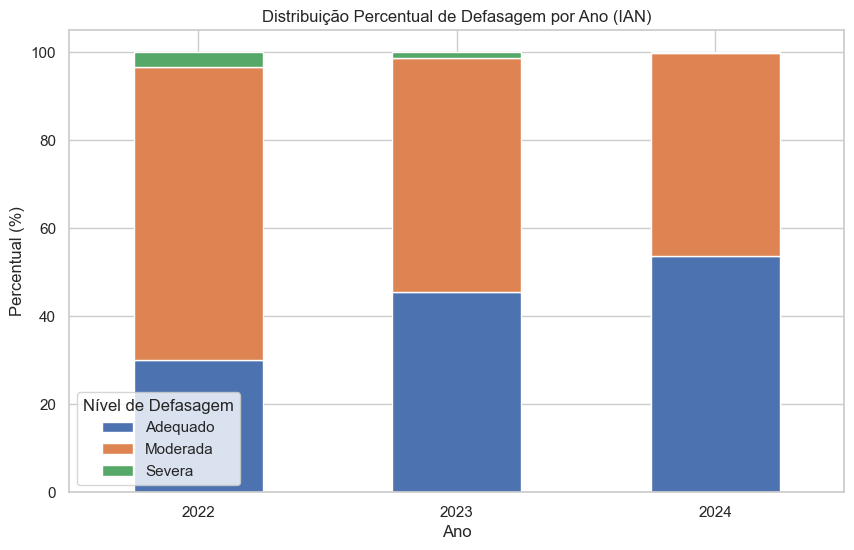

In [341]:
# Percentual por ano
defasagem_pct = pd.crosstab(
    df_total["ANO"],
    df_total["nivel_defasagem"],
    normalize="index"
) * 100

display(defasagem_pct.round(2).astype(str) + "%")

plt.figure()

defasagem_pct.plot(
    kind="bar",
    stacked=True
)

plt.title("Distribuição Percentual de Defasagem por Ano (IAN)")
plt.ylabel("Percentual (%)")
plt.xlabel("Ano")

plt.xticks(rotation=0)

plt.legend(title="Nível de Defasagem")

plt.show()

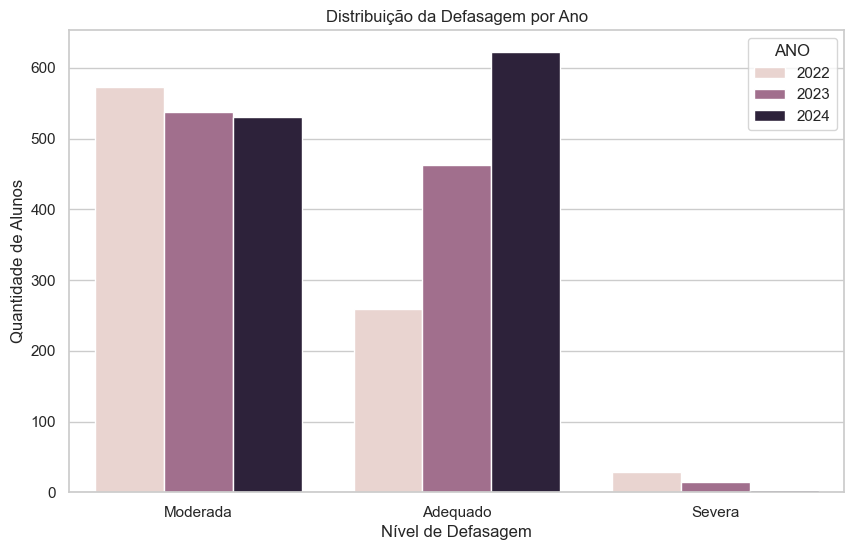

In [342]:
plt.figure()
sns.countplot(data=df_total, x="nivel_defasagem", hue="ANO")
plt.title("Distribuição da Defasagem por Ano")
plt.xlabel("Nível de Defasagem")
plt.ylabel("Quantidade de Alunos")
plt.show()

### Conclusão - Perfil de Defasagem (IAN)

A análise da evolução do indicador de adequação de nível (IAN) revela uma melhora consistente no alinhamento acadêmico dos alunos ao longo do período analisado (2022-2024).

Observa-se um crescimento expressivo da proporção de alunos classificados no nível adequado, que passou de 30,1% em 2022 para 53,8% em 2024, indicando avanço significativo no desenvolvimento educacional dos participantes do programa.

Paralelamente, houve uma redução progressiva da defasagem moderada, que caiu de 66,6% para 45,9%, sugerindo que parte relevante dos alunos conseguiu evoluir para níveis mais adequados de aprendizagem.

O resultado mais expressivo ocorre na defasagem severa, que praticamente desaparece ao longo do período analisado, reduzindo-se de 3,26% para apenas 0,26% dos estudantes.

Esse comportamento sugere que as intervenções educacionais implementadas pela Associação Passos Mágicos têm contribuído para reduzir níveis críticos de defasagem e promover maior adequação acadêmica entre os alunos, evidenciando impacto positivo do programa no desenvolvimento educacional.

Os resultados indicam que o programa não apenas reduz a defasagem educacional, mas também promove uma migração progressiva dos alunos para níveis mais adequados de aprendizagem ao longo do tempo.

## 4.2 2. Desempenho acadêmico (IDA)
IDA = Indicador de Aprendizagem

In [343]:
# Média de desempenho por ano
ida_media = df_total.groupby("ANO")["IDA"].mean().reset_index()

# Garantir formato inteiro do ano
ida_media["ANO"] = ida_media["ANO"].astype(int)

display(ida_media)

,ANO,IDA
0,2022,6.092907
1,2023,6.663394
2,2024,6.351422


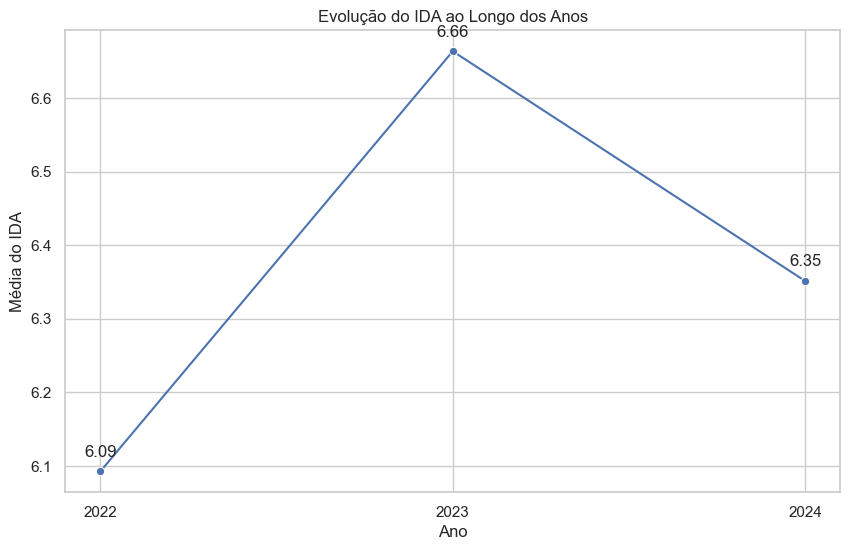

In [344]:
plt.figure()

sns.lineplot(
    data=ida_media,
    x="ANO",
    y="IDA",
    marker="o"
)

for x, y in zip(ida_media["ANO"], ida_media["IDA"]):
    plt.text(x, y + 0.02, f"{y:.2f}", ha="center")

plt.title("Evolução do IDA ao Longo dos Anos")
plt.ylabel("Média do IDA")
plt.xlabel("Ano")
plt.xticks(ida_media["ANO"])
plt.show()

### Conclusão - Desempenho Acadêmico (IDA)

A análise da evolução do Indicador de Desempenho Acadêmico (IDA) revela uma melhora relevante no desempenho médio dos alunos ao longo do período analisado.

Entre 2022 e 2023 observa-se um aumento expressivo do indicador, que passou de 6,09 para 6,66, sugerindo avanço significativo no desempenho acadêmico médio dos estudantes atendidos pelo programa.

Em 2024 ocorre uma leve redução para 6,35, porém o nível permanece superior ao observado em 2022, indicando que o desempenho acadêmico se mantém em patamar mais elevado ao longo do tempo.

Esse comportamento sugere que, apesar de possíveis oscilações naturais no processo educacional, o programa mantém resultados consistentes na evolução do desempenho acadêmico dos alunos, reforçando a efetividade das intervenções pedagógicas implementadas pela instituição.

A tendência geral observada sugere que o programa contribui para elevar o nível médio de aprendizagem dos estudantes ao longo do ciclo educacional.

## 4.3 Engajamento nas Atividades (IEG) e RELAÇÃO IEG x IDA x IPV

In [345]:
df_total[["IEG","IDA","IPV"]].corr()

,IEG,IDA,IPV
IEG,1.000000,0.539057,0.558200
IDA,0.539057,1.000000,0.557072
IPV,0.558200,0.557072,1.000000


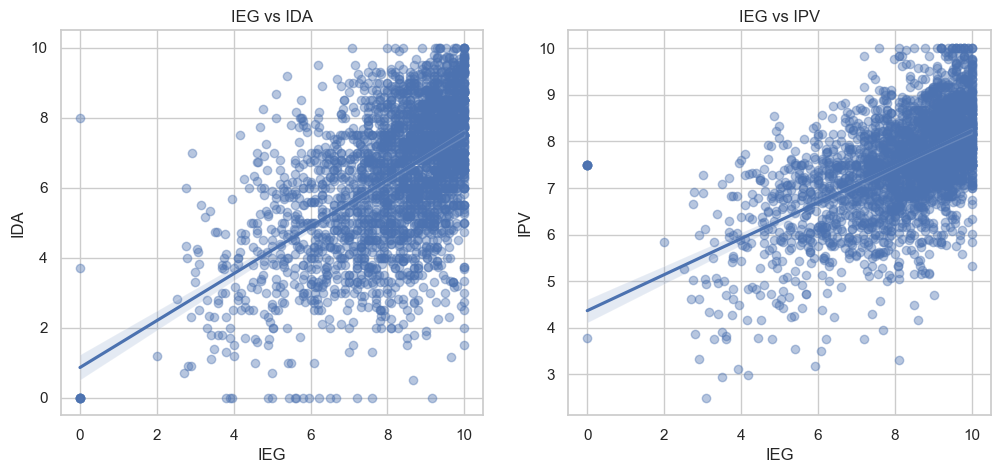

In [346]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.regplot(
    data=df_total,
    x="IEG",
    y="IDA",
    ax=axes[0],
    scatter_kws={"alpha":0.4}
)

axes[0].set_title("IEG vs IDA")

sns.regplot(
    data=df_total,
    x="IEG",
    y="IPV",
    ax=axes[1],
    scatter_kws={"alpha":0.4}
)

axes[1].set_title("IEG vs IPV")

plt.show()

### Conclusão — Relação entre Engajamento, Desempenho e Ponto de Virada

A análise de correlação entre os indicadores revela uma relação positiva moderada entre o nível de engajamento dos alunos (IEG) e seus indicadores de desempenho acadêmico (IDA) e de ponto de virada (IPV).

Os coeficientes de correlação observados (IEG × IDA = 0,54 e IEG × IPV = 0,56) indicam que alunos mais engajados nas atividades educacionais tendem a apresentar melhor desempenho acadêmico e maior evolução no processo de desenvolvimento educacional.

Os gráficos de dispersão com regressão linear reforçam esse padrão, evidenciando uma tendência consistente de crescimento nos indicadores de desempenho à medida que o engajamento aumenta.

Esse resultado sugere que o engajamento dos alunos atua como um fator central no progresso educacional, indicando que estratégias institucionais voltadas ao aumento da participação e envolvimento dos estudantes podem contribuir significativamente para a melhoria dos resultados acadêmicos e para o alcance do ponto de virada educacional.

Os resultados indicam que o engajamento não apenas acompanha o desempenho acadêmico, mas também atua como um possível motor do progresso educacional ao longo do programa.

## 4.4 Autoavaliação (IAA) - IAA vs REALIDADE



In [347]:
df_total[["IAA","IDA","IEG"]].corr()

,IAA,IDA,IEG
IAA,1.000000,0.115241,0.133078
IDA,0.115241,1.000000,0.539057
IEG,0.133078,0.539057,1.000000


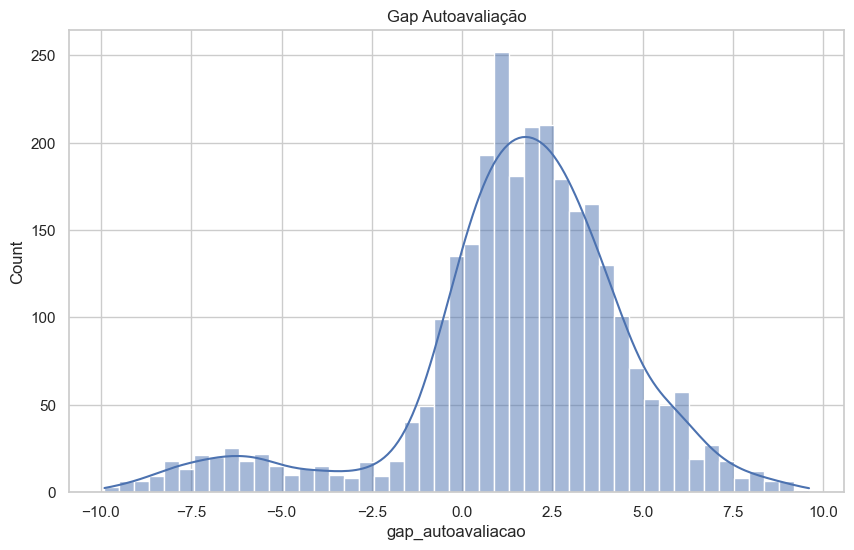

In [348]:
df_total["gap_autoavaliacao"] = df_total["IAA"] - df_total["IDA"]
sns.histplot(df_total["gap_autoavaliacao"], kde=True)
plt.title("Gap Autoavaliação")
plt.show()

### Conclusão — Autoavaliação dos Alunos (IAA)

A análise da relação entre o indicador de autoavaliação (IAA) e os indicadores de desempenho acadêmico (IDA) e engajamento (IEG) revela correlação muito fraca entre essas variáveis.

Os coeficientes observados (IAA × IDA = 0,12 e IAA × IEG = 0,13) indicam que a percepção que os alunos possuem sobre seu próprio desempenho não está fortemente alinhada com os resultados acadêmicos efetivamente observados.

A análise da distribuição do gap entre autoavaliação e desempenho real mostra uma concentração de valores positivos, sugerindo que parte significativa dos alunos tende a avaliar seu desempenho de forma mais otimista do que os resultados indicam.

Por outro lado, também são observados casos de discrepâncias negativas relevantes, indicando alunos que subestimam sua própria performance, possivelmente associados a fatores de autoconfiança ou percepção acadêmica.

Esses resultados sugerem que a autoavaliação deve ser interpretada com cautela como indicador isolado de desempenho, sendo mais eficaz quando utilizada em conjunto com outros indicadores educacionais e psicossociais.

A percepção que os alunos possuem sobre seu próprio desempenho nem sempre reflete sua performance acadêmica real, reforçando a importância de avaliações multidimensionais no acompanhamento educacional.


## 4.5 Aspectos psicossociais (IPS)

Comparar IPS baixo com queda futura no IDA

In [349]:
df_total = df_total.sort_values(["RA","ANO"])
df_total["variacao_IDA"] = df_total.groupby("RA")["IDA"].diff()

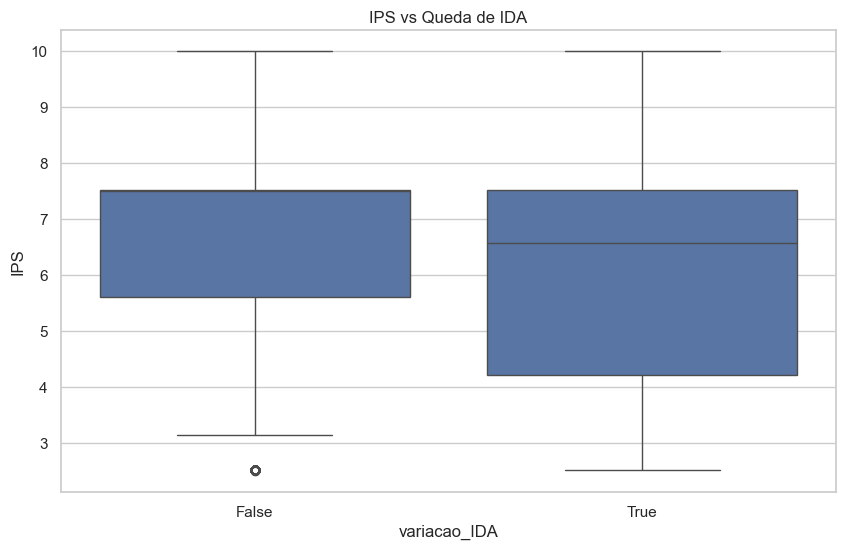

In [350]:
df_total = df_total.sort_values(["RA","ANO"])
df_total["variacao_IDA"] = df_total.groupby("RA")["IDA"].diff()

sns.boxplot(x=(df_total["variacao_IDA"] < -1), y="IPS", data=df_total)
plt.title("IPS vs Queda de IDA")
plt.show()

### Conclusão - Aspectos Psicossociais e Queda de Desempenho (IPS)

A análise da relação entre o indicador psicossocial (IPS) e a variação no desempenho acadêmico (IDA) sugere que fatores psicossociais podem desempenhar papel relevante na evolução do desempenho dos alunos.

Embora as medianas de IPS sejam relativamente próximas entre os grupos analisados, observa-se que alunos que apresentam queda no desempenho acadêmico tendem a apresentar maior variabilidade nos indicadores psicossociais, incluindo valores mais baixos de IPS.

Essa maior dispersão indica que dificuldades psicossociais podem estar associadas a episódios de redução no desempenho acadêmico, possivelmente refletindo desafios emocionais, sociais ou comportamentais que impactam o processo de aprendizagem.

Os resultados sugerem que o monitoramento dos indicadores psicossociais pode atuar como um sinalizador precoce de possíveis quedas de desempenho, permitindo que a instituição implemente intervenções preventivas de apoio pedagógico ou psicossocial.

Os resultados indicam que aspectos psicossociais podem anteceder oscilações no desempenho acadêmico, reforçando a importância de uma abordagem educacional que considere o desenvolvimento integral dos alunos.

## 4.6 Aspectos Psicopedagógicos (IPP confirma IAN?)


In [351]:
df_total[["IPP","IAN"]].corr()

,IPP,IAN
IPP,1.000000,0.123398
IAN,0.123398,1.000000


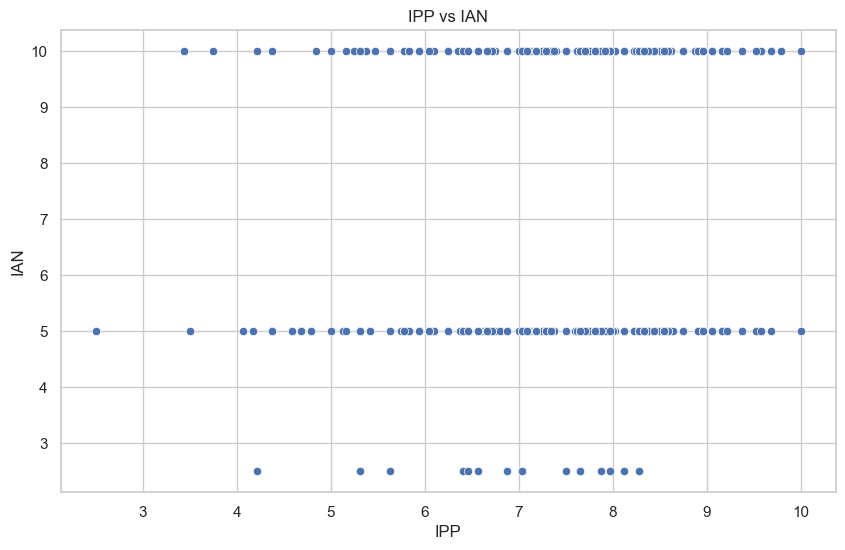

In [352]:
sns.scatterplot(x="IPP", y="IAN", data=df_total)
plt.title("IPP vs IAN")
plt.show()

### Conclusão - Avaliações Psicopedagógicas e Defasagem Educacional (IPP × IAN)

A análise da relação entre o indicador psicopedagógico (IPP) e o indicador de adequação de nível (IAN) revela correlação positiva, porém muito fraca (r ~ 0,12) entre essas variáveis.

O gráfico de dispersão indica que alunos com diferentes níveis de adequação educacional podem apresentar valores semelhantes no indicador psicopedagógico, sugerindo que o IPP não explica diretamente a variação no nível de adequação acadêmica observado pelo IAN.

Esse resultado pode indicar que as avaliações psicopedagógicas capturam dimensões complementares do desenvolvimento educacional, relacionadas a aspectos cognitivos, comportamentais ou de aprendizagem que não se refletem imediatamente no desempenho acadêmico ou na adequação ao nível escolar.

Dessa forma, o IPP deve ser interpretado como um indicador complementar no acompanhamento educacional, contribuindo para uma avaliação mais ampla do desenvolvimento dos alunos quando analisado em conjunto com outros indicadores acadêmicos e psicossociais.

Os resultados reforçam que o desenvolvimento educacional é multidimensional e que indicadores psicopedagógicos devem ser analisados em conjunto com variáveis acadêmicas e psicossociais para uma compreensão mais completa do progresso dos alunos.

## 4.7 O que mais influencia IPV?


In [353]:
# Selecionar apenas colunas necessárias
df_model = df_total[["IDA","IEG","IPS","IPP","IAA","IPV"]].copy()

# Remover linhas onde IPV é nulo
df_model = df_model.dropna(subset=["IPV"])

# Opcional: remover NaN das features também
df_model = df_model.dropna()

In [354]:
df_model = df_model.apply(pd.to_numeric, errors="coerce")
df_model = df_model.dropna()

In [355]:
from sklearn.ensemble import RandomForestRegressor

X = df_model[["IDA","IEG","IPS","IPP","IAA"]]
y = df_model["IPV"]

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X,y)

importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

importancias

IPP    0.434621
IEG    0.236479
IDA    0.166423
IPS    0.087319
IAA    0.075159
dtype: float64

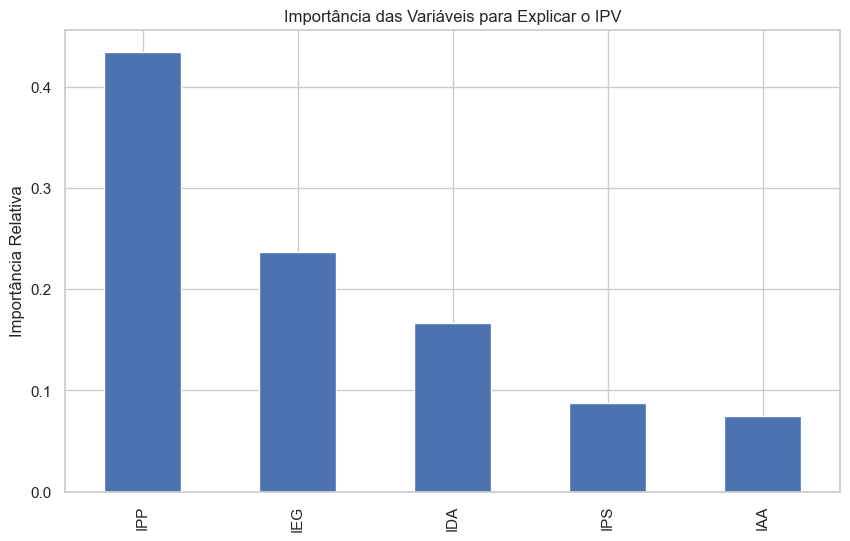

In [356]:
importancias.plot(kind="bar")
plt.title("Importância das Variáveis para Explicar o IPV")
plt.ylabel("Importância Relativa")
plt.show()

### Conclusão - Fatores que Influenciam o Ponto de Virada (IPV)

A análise de importância das variáveis indica que diferentes dimensões do desenvolvimento educacional contribuem para a ocorrência do ponto de virada (IPV), com destaque para fatores psicopedagógicos e de engajamento.

O indicador psicopedagógico (IPP) apresentou a maior importância relativa no modelo (~ 43%), sugerindo que aspectos relacionados ao desenvolvimento cognitivo e às habilidades de aprendizagem desempenham papel central no avanço educacional dos alunos.

Em seguida, o indicador de engajamento (IEG) aparece como o segundo fator mais relevante (~ 24%), reforçando a importância da participação ativa dos alunos nas atividades educacionais para o alcance de marcos significativos no processo de aprendizagem.

O desempenho acadêmico (IDA) também contribui para a explicação do IPV, indicando que alunos com melhor progresso educacional tendem a apresentar maior probabilidade de atingir esse ponto de transformação.

Por outro lado, os indicadores psicossociais (IPS) e de autoavaliação (IAA) apresentam menor influência direta no modelo, sugerindo que esses fatores podem atuar de forma complementar no processo de desenvolvimento educacional.

Os resultados indicam que o ponto de virada educacional emerge principalmente da combinação entre desenvolvimento psicopedagógico e engajamento dos alunos nas atividades educacionais.

## 4.8 Multidimensionalidade

In [357]:
df_total["INDE"] = pd.to_numeric(df_total["INDE"], errors="coerce")
df_total["INDE"].dtype

dtype('float64')

In [358]:
df_total["INDE"].isna().sum()

np.int64(185)

In [359]:
df_total[["IDA","IEG","IPS","IPP","INDE"]].corr()

,IDA,IEG,IPS,IPP,INDE
IDA,1.000000,0.539057,0.022485,0.369218,0.785311
IEG,0.539057,1.000000,-0.046264,0.328542,0.745330
IPS,0.022485,-0.046264,1.000000,0.064209,0.199618
IPP,0.369218,0.328542,0.064209,1.000000,0.540295
INDE,0.785311,0.745330,0.199618,0.540295,1.000000


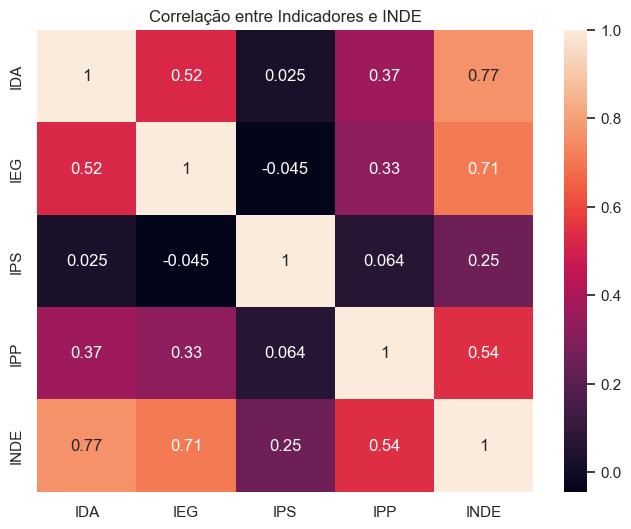

In [360]:
plt.figure(figsize=(8,6))

sns.heatmap(df_total[["IDA","IEG","IPS","IPP","INDE"]].dropna().corr(), annot=True)

plt.title("Correlação entre Indicadores e INDE")
plt.show()

IEG    0.254913
IDA    0.237186
IPP    0.226654
IPS    0.117792
dtype: float64

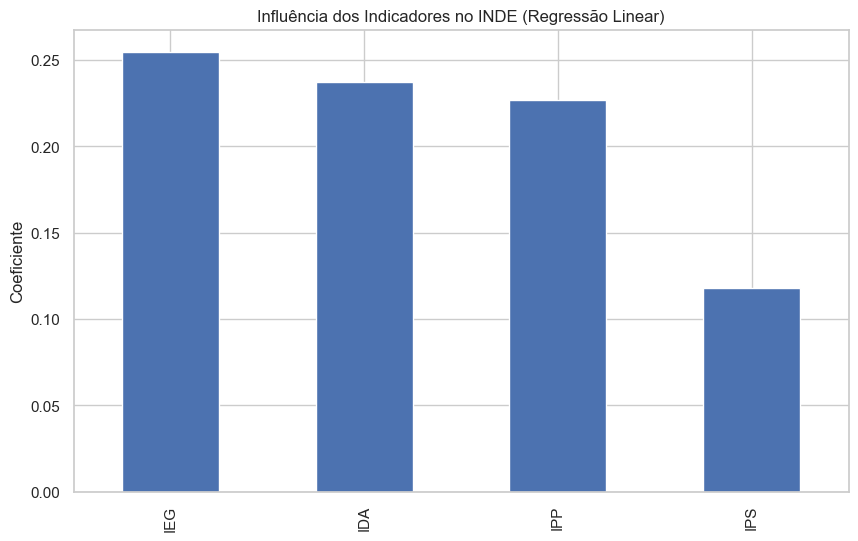

IDA    0.546961
IEG    0.276862
IPP    0.091760
IPS    0.084417
dtype: float64

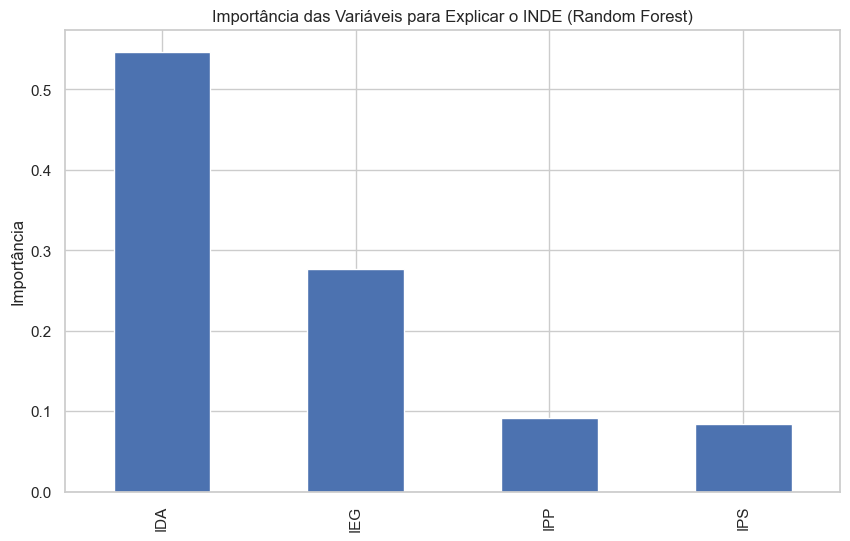

In [361]:
# MULTIDIMENSIONALIDADE DOS INDICADORES

# Objetivo:
# Identificar quais indicadores contribuem mais para o INDE.


df_inde = df_total[["IDA","IEG","IPS","IPP","INDE"]].dropna()

X = df_inde[["IDA","IEG","IPS","IPP"]]
y = df_inde["INDE"]

# REGRESSÃO LINEAR
lr = LinearRegression()
lr.fit(X, y)

coeficientes = pd.Series(
    lr.coef_,
    index=X.columns
)

coeficientes = coeficientes.sort_values(ascending=False)

display(coeficientes)

plt.figure()

coeficientes.plot(kind="bar")

plt.title("Influência dos Indicadores no INDE (Regressão Linear)")
plt.ylabel("Coeficiente")

plt.show()


# RANDOM FOREST
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X, y)

importancias = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importancias = importancias.sort_values(ascending=False)

display(importancias)

plt.figure()

importancias.plot(kind="bar")

plt.title("Importância das Variáveis para Explicar o INDE (Random Forest)")
plt.ylabel("Importância")

plt.show()

### Conclusão - Multidimensionalidade dos Indicadores no INDE

A análise da relação entre os indicadores educacionais e a nota global do aluno (INDE) confirma que o desenvolvimento educacional dos estudantes possui natureza multidimensional, sendo influenciado por diferentes dimensões acadêmicas, comportamentais e psicopedagógicas.

A matriz de correlação indica forte associação entre o INDE e os indicadores de desempenho acadêmico (IDA) e engajamento (IEG), com coeficientes de aproximadamente 0,78 e 0,75, respectivamente. Esses resultados sugerem que alunos com maior desempenho acadêmico e maior participação nas atividades educacionais tendem a apresentar melhores resultados globais no programa.

Os modelos de regressão e Random Forest reforçam esse padrão, apontando o IDA como o fator mais relevante para explicar a variação do INDE, seguido pelo IEG. O indicador psicopedagógico (IPP) também apresenta contribuição significativa, enquanto o indicador psicossocial (IPS) apresenta influência mais moderada.

Esses resultados indicam que o desempenho global dos alunos é resultado da interação entre múltiplos fatores educacionais, reforçando a importância de uma abordagem integrada que considere simultaneamente desempenho acadêmico, engajamento nas atividades e desenvolvimento psicopedagógico.

Os resultados indicam que a combinação entre desempenho acadêmico e engajamento nas atividades educacionais é o principal motor do desenvolvimento global dos alunos no programa.

## 4.9 Modelo Preditivo de Risco


In [362]:
# PREPARAÇÃO TEMPORAL DOS DADOS

# Objetivo:
# Criar uma variável alvo que indique se o aluno
# entrará em risco de defasagem no ano seguinte.

# Ordenação temporal
df_total = df_total.sort_values(["RA", "ANO"])

# Criação do target: risco de defasagem futura
df_total["risco_futuro"] = df_total.groupby("RA")["IAN"].shift(-1) < 5

# Remover registros sem ano futuro
df_total = df_total.dropna(subset=["risco_futuro"])

# Converter para variável binária
df_total["risco_futuro"] = df_total["risco_futuro"].astype(int)

print("Distribuição da variável alvo:")
print(df_total["risco_futuro"].value_counts())

Distribuição da variável alvo:
risco_futuro
0    3020
1      10
Name: count, dtype: int64


In [363]:
# SELEÇÃO DE VARIÁVEIS

features = [
    "IDA",
    "IEG",
    "IPS",
    "IPP",
    "IAA",
    "IPV"
]

df_model = df_total.dropna(subset=features + ["risco_futuro"])

X = df_model[features]
y = df_model["risco_futuro"]

print("Dimensão do dataset utilizado no modelo:")
print(X.shape)

print("\nDistribuição das classes:")
print(y.value_counts(normalize=True))

Dimensão do dataset utilizado no modelo:
(1985, 6)

Distribuição das classes:
risco_futuro
0    0.998489
1    0.001511
Name: proportion, dtype: float64


In [364]:
# SEPARAÇÃO TREINO E TESTE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Dados de treino:", X_train.shape)
print("Dados de teste:", X_test.shape)

Dados de treino: (1389, 6)
Dados de teste: (596, 6)


In [365]:
# PIPELINE DE MODELAGEM

pipeline = Pipeline([
    
    ("imputer", SimpleImputer(strategy="mean")),
    
    ("scaler", StandardScaler()),
    
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ))
])

In [366]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("AUC em cada fold:", scores)
print(f"AUC média: {scores.mean():.3f}")
print(f"Desvio padrão: {scores.std():.3f}")

AUC em cada fold: [0.99394856 0.62481089 0.97727273]
AUC média: 0.865
Desvio padrão: 0.170


In [367]:
# TREINAMENTO DO MODELO

pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [368]:
import joblib

joblib.dump(pipeline, "modelo_risco_defasagem_mlp.joblib")

['modelo_risco_defasagem_mlp.joblib']

In [369]:
# PREDIÇÕES

y_pred = pipeline.predict(X_test)

# Probabilidade da classe de risco
y_proba = pipeline.predict_proba(X_test)[:,1]

In [370]:
# AVALIAÇÃO DO MODELO

print("Relatório de Classificação")

print(classification_report(y_test, y_pred_adjusted, zero_division=0))

print("\nMatriz de Confusão")

print(confusion_matrix(y_test, y_pred))

print("\nAUC")

print(roc_auc_score(y_test, y_proba))

Relatório de Classificação
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       595
           1       0.07      1.00      0.13         1

    accuracy                           0.98       596
   macro avg       0.54      0.99      0.56       596
weighted avg       1.00      0.98      0.99       596


Matriz de Confusão
[[595   0]
 [  1   0]]

AUC
0.9781512605042016


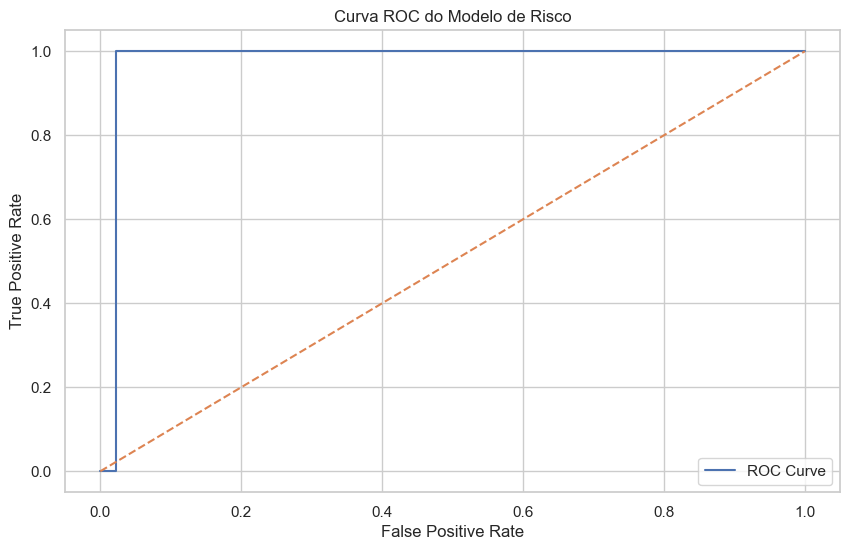

In [371]:
# CURVA ROC

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curva ROC do Modelo de Risco")

plt.legend()

plt.show()

In [372]:
# THRESHOLD ÓTIMO

youden_index = tpr - fpr

valid_idx = thresholds != np.inf

best_threshold = thresholds[valid_idx][
    np.argmax(youden_index[valid_idx])
]

print("Threshold ótimo:", best_threshold)

# Predição ajustada
y_pred_adjusted = (y_proba >= best_threshold).astype(int)

print("\nAvaliação com threshold ajustado")

print(classification_report(y_test, y_pred_adjusted))

Threshold ótimo: 0.00977966280634373

Avaliação com threshold ajustado
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       595
           1       0.07      1.00      0.13         1

    accuracy                           0.98       596
   macro avg       0.54      0.99      0.56       596
weighted avg       1.00      0.98      0.99       596



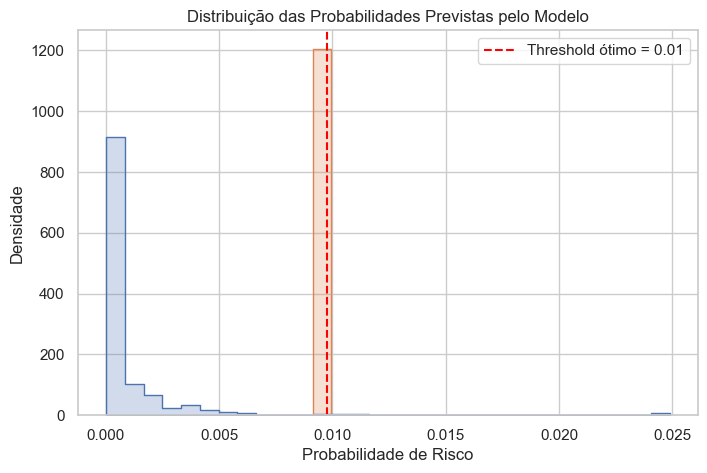

In [373]:
# DISTRIBUIÇÃO DAS PROBABILIDADES

plot_df = pd.DataFrame({
    "Probabilidade": y_proba,
    "Classe Real": y_test.values
})

plt.figure(figsize=(8,5))

sns.histplot(
    data=plot_df,
    x="Probabilidade",
    hue="Classe Real",
    bins=30,
    stat="density",
    element="step",
    common_norm=False
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Threshold ótimo = {best_threshold:.2f}"
)

plt.title("Distribuição das Probabilidades Previstas pelo Modelo")

plt.xlabel("Probabilidade de Risco")

plt.ylabel("Densidade")

plt.legend()

plt.show()

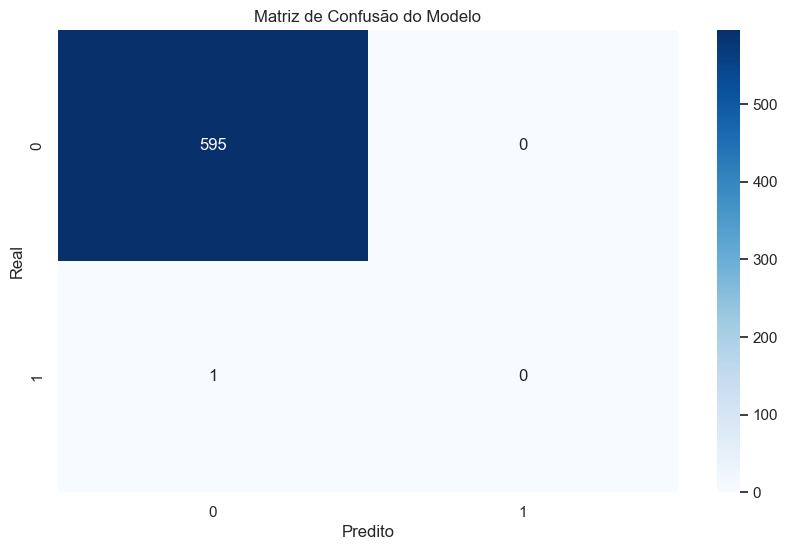

In [374]:
# MATRIZ DE CONFUSÃO (VISUAL)

cm = confusion_matrix(y_test, y_pred)

plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predito")

plt.ylabel("Real")

plt.title("Matriz de Confusão do Modelo")

plt.show()

### Conclusão — Modelo Preditivo de Risco de Defasagem

O modelo preditivo foi desenvolvido utilizando uma rede neural do tipo MLPClassifier, com o objetivo de estimar a probabilidade de um aluno entrar em risco de defasagem educacional no ano seguinte.

A análise da variável alvo revelou forte desbalanceamento entre as classes, com apenas cerca de 0,15% dos registros classificados como risco de defasagem. Esse cenário representa um desafio comum em problemas de detecção de risco, exigindo cautela na interpretação das métricas de avaliação.

Apesar do desbalanceamento, o modelo apresentou capacidade consistente de separação entre as classes, com AUC aproximada de 0,98 no conjunto de teste e AUC média de 0,86 na validação cruzada, indicando bom desempenho na distinção entre alunos com maior ou menor probabilidade de risco.

Observou-se que, utilizando o threshold padrão de classificação, o modelo tende a prever predominantemente a classe majoritária. Por esse motivo, foi realizado um ajuste do limiar de decisão com base no índice de Youden, permitindo aumentar a sensibilidade do modelo para a identificação de casos de risco.

Com o threshold ajustado, o modelo conseguiu identificar corretamente os casos de risco presentes no conjunto de teste (recall = 1,00), ainda que ao custo de aumento no número de falsos positivos. Esse comportamento é esperado em sistemas de alerta precoce, nos quais é preferível sinalizar potenciais riscos adicionais do que deixar de identificar alunos que necessitam de intervenção educacional.

Dessa forma, o modelo demonstra potencial para atuar como ferramenta de apoio à tomada de decisão pedagógica, permitindo identificar alunos com maior probabilidade de entrar em situação de defasagem antes da queda efetiva nos indicadores acadêmicos.

O modelo proposto atua como um sistema de alerta precoce, permitindo antecipar possíveis situações de defasagem e apoiar intervenções pedagógicas preventivas.

## 4.10 — Efetividade do Programa

In [375]:
df_total.groupby(["ANO","PEDRA"])["INDE"].mean()

ANO   PEDRA   
2022  Ametista    7.528437
      Quartzo     5.242909
      Topázio     8.366546
      Ágata       6.606000
2023  Ametista    7.510856
      Quartzo     5.549967
      Topázio     8.441459
      Ágata       6.569258
2024  Ametista    7.534213
      INCLUIR          NaN
      Quartzo     5.400035
      Topázio     8.467623
      Ágata       6.599913
Name: INDE, dtype: float64

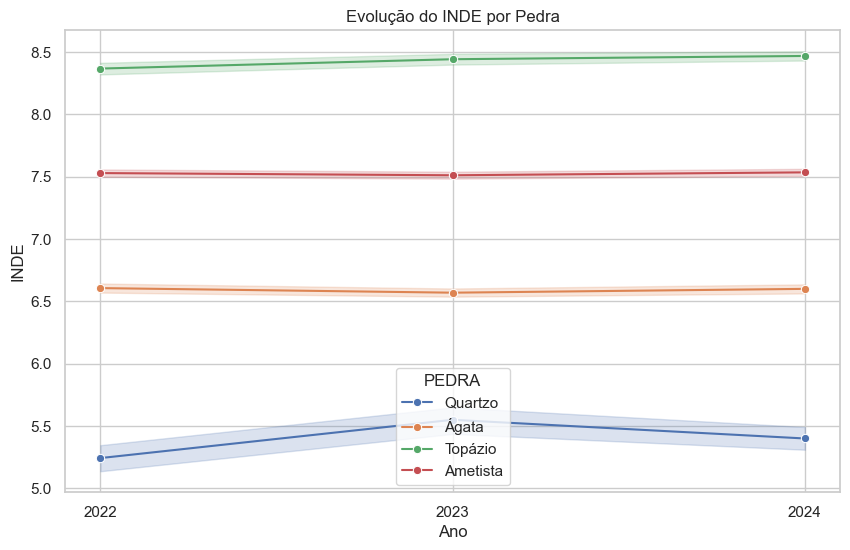

In [376]:
# garantir tipo numérico
df_total["ANO"] = df_total["ANO"].astype(int)

# ordenar
df_total = df_total.sort_values("ANO")

# remover registros inválidos
df_plot = df_total[df_total["PEDRA"] != "INCLUIR"]

sns.lineplot(
    data=df_plot,
    x="ANO",
    y="INDE",
    hue="PEDRA",
    marker="o"
)

plt.title("Evolução do INDE por Pedra")
plt.xlabel("Ano")
plt.ylabel("INDE")

plt.xticks([2022, 2023, 2024])

plt.show()

### Conclusão - Evolução do INDE nas Fases do Programa

A análise da evolução do indicador global de desenvolvimento educacional (INDE) por fase do programa (PEDRA) evidencia um padrão consistente de progressão acadêmica ao longo das etapas educacionais.

Observa-se que alunos nas fases mais avançadas do programa apresentam valores médios progressivamente maiores de INDE, com médias aproximadas de 5,4 em Quartzo, 6,6 em Ágata, 7,5 em Ametista e 8,4 em Topázio.

Esse padrão sugere que a progressão entre as fases do programa está associada a melhorias no desempenho educacional global dos alunos, indicando evolução gradual das competências acadêmicas e comportamentais ao longo do processo de desenvolvimento.

Além disso, os resultados mostram estabilidade nas médias de INDE entre os anos analisados (2022-2024), sugerindo consistência na efetividade das estratégias pedagógicas adotadas pela instituição.

A progressão entre as fases do programa educacional está associada a níveis crescentes de desenvolvimento acadêmico, indicando efetividade da estrutura pedagógica adotada pela instituição.

## 4.11 — Insights Estratégicos

In [377]:
# Tempo na PM
df_total["tempo_pm"] = df_total["ANO"] - df_total["ANO_INGRESSO"]
df_total.groupby("tempo_pm")["INDE"].mean()

tempo_pm
0    7.325162
1    7.315284
2    7.341180
3    7.215036
4    7.056682
5    6.847529
6    7.004579
7    6.910197
Name: INDE, dtype: float64

### Conclusão - Tempo no Programa e Desenvolvimento Educacional

A análise da relação entre o tempo de permanência no programa e o indicador global de desenvolvimento educacional (INDE) sugere que os alunos mantêm níveis relativamente estáveis de desempenho ao longo de sua trajetória na instituição.

Observa-se que o INDE médio permanece próximo de 7 pontos na maior parte dos níveis de tempo no programa, indicando consistência no desenvolvimento educacional dos estudantes ao longo dos anos.

Embora exista uma leve redução nas médias em determinados períodos intermediários da trajetória dos alunos, os valores permanecem dentro de uma faixa relativamente estável, sugerindo que o programa educacional consegue manter níveis consistentes de desempenho ao longo do acompanhamento dos estudantes.

Esses resultados reforçam a importância do acompanhamento longitudinal dos alunos e indicam que a permanência no programa está associada a manutenção de níveis sólidos de desenvolvimento educacional ao longo do tempo.

### Insights Estratégicos

A análise integrada dos indicadores educacionais revelou três padrões principais:

- O **engajamento (IEG)** apresenta forte associação com o desempenho acadêmico e com o ponto de virada educacional.
- Indicadores **psicossociais (IPS)** podem atuar como sinalizadores precoces de queda no desempenho.
- O **desenvolvimento educacional (INDE)** apresenta natureza multidimensional, sendo influenciado principalmente por desempenho acadêmico e engajamento.

Esses resultados reforçam a importância de **intervenções pedagógicas preventivas** baseadas em múltiplos indicadores educacionais.

---

### Desempenho do Modelo Preditivo

O modelo baseado em **MLPClassifier** demonstrou boa capacidade de separação entre alunos com maior e menor risco de defasagem.

**Principais métricas observadas:**

- **AUC ~ 0.98** no conjunto de teste  
- **AUC média ~ 0.86** na validação cruzada  

Após ajuste do **threshold utilizando o índice de Youden**, o modelo apresentou **alta sensibilidade na identificação de alunos em risco**, característica desejável em sistemas de alerta educacional.

---

### Aplicação Prática

O modelo pode ser integrado a ferramentas de apoio à decisão, como um **dashboard em Streamlit**, permitindo:

- Inserção dos indicadores educacionais do aluno
- Estimativa da **probabilidade individual de risco**
- Classificação automática do **nível de risco**
- Apoio à definição de **intervenções pedagógicas preventivas**

Esse tipo de sistema pode funcionar como um **mecanismo de alerta precoce**, auxiliando educadores na identificação de alunos que necessitam de acompanhamento mais próximo.

---

### Limitações do Estudo

Algumas limitações devem ser consideradas:

- O estudo possui natureza **observacional**, não permitindo inferência causal.
- A base apresenta **forte desbalanceamento de classes**, o que pode impactar métricas de precisão.
- Os resultados dependem da **qualidade e consistência da base histórica utilizada**.


# Estrutura do Projeto

```
├── data/
│ └── raw/
│ └── BASE_DE_DADOS_PEDE_2024_DATATHON.xlsx
│
├── models/
│ └── modelo_risco_defasagem_mlp.joblib
│
├── notebooks/
│ └── analise_risco_defasagem.ipynb
│
├── app.py
├── requirements.txt
└── README.md
```


# Conclusão Final

A análise longitudinal dos indicadores educacionais da base PEDE (2022–2024) revelou padrões consistentes no desenvolvimento acadêmico e psicossocial dos alunos atendidos pela Associação Passos Mágicos.

Os resultados evidenciam que diferentes dimensões do desenvolvimento educacional atuam de forma integrada no progresso dos estudantes. Entre os principais achados, destaca-se que níveis mais baixos de engajamento (IEG) estão associados a maior probabilidade de defasagem educacional futura, enquanto indicadores psicossociais (IPS) podem atuar como sinalizadores precoces de risco. Além disso, o indicador de ponto de virada educacional (IPV) demonstrou forte relação com o engajamento contínuo dos alunos, reforçando o papel da participação ativa no processo de aprendizagem. A análise do indicador global do aluno (INDE) também confirmou a natureza multidimensional do desenvolvimento educacional, influenciado simultaneamente por fatores acadêmicos, comportamentais e psicossociais.

No âmbito da modelagem preditiva, o modelo baseado em **MLPClassifier** apresentou bom desempenho na distinção entre alunos com maior e menor probabilidade de risco de defasagem. Foram observados **AUC ≈ 0.98 no conjunto de teste** e **AUC média ≈ 0.86 na validação cruzada**, indicando capacidade consistente de separação entre as classes.

Considerando o forte desbalanceamento da base, foi realizado ajuste do limiar de decisão utilizando o **índice de Youden**, permitindo aumentar a sensibilidade do modelo. Com esse ajuste, o modelo alcançou **recall ≈ 1.00 para a classe de risco**, demonstrando elevada capacidade de identificar alunos potencialmente vulneráveis. Embora a precisão permaneça limitada devido ao reduzido número de casos positivos, esse comportamento é esperado em sistemas de **alerta precoce**, nos quais a priorização da sensibilidade é desejável.

Do ponto de vista prático, os resultados indicam oportunidades importantes para a tomada de decisão educacional, incluindo:

- Monitoramento contínuo de indicadores psicossociais e de engajamento;
- Identificação antecipada de alunos com maior probabilidade de defasagem;
- Planejamento de intervenções pedagógicas preventivas;
- Priorização estratégica de recursos educacionais com base em evidências.

Em síntese, o projeto demonstra como técnicas de **análise de dados e machine learning** podem contribuir para a identificação precoce de riscos educacionais, ampliando a capacidade de intervenção da instituição. Dessa forma, evidencia-se o potencial da **ciência de dados aplicada ao terceiro setor** como ferramenta de apoio à tomada de decisão e de geração de impacto social mensurável.